<a href="https://colab.research.google.com/github/yuweimin2077-hub/xsim-chip/blob/main/notebooks/02_astra_colab_gpu_smoke.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab GPU smoke test: package slice → projections → FBP reconstruction

This notebook validates a reproducible, low-memory ASTRA pipeline before scaling to the full NIST phantom. It uses **relative monoenergetic attenuation**, not a calibrated gVXR spectrum. Select **Runtime → Change runtime type → T4 GPU** for the CUDA path.

In [3]:
from pathlib import Path
repo = Path('/content/xsim-chip')
if repo.exists():
    !git -C {repo} pull --ff-only
else:
    !git clone -q https://github.com/yuweimin2077-hub/xsim-chip.git {repo}
%cd /content/xsim-chip
%pip install -q -e '.[simulation]'

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 9 (delta 5), reused 9 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 1.03 KiB | 529.00 KiB/s, done.
From https://github.com/yuweimin2077-hub/xsim-chip
   dac5427..01780e2  main       -> origin/main
Updating dac5427..01780e2
Fast-forward
 .github/workflows/tests.yml | 3 +--
 MODIFICATIONS.md            | 2 ++
 docs/COLAB_GPU_WORKFLOW.md  | 6 +++++-
 pyproject.toml              | 2 +-
 4 files changed, 9 insertions(+), 4 deletions(-)
/content/xsim-chip
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 9.5 MB/s eta 0:00:00
  Building edi

In [4]:
import json
import time
import astra
import matplotlib.pyplot as plt
import numpy as np
from xsim_chip_analysis import (
    SimulationConfig, build_run_manifest, estimate_memory,
    inject_demo_defects, make_package_slice, material_to_attenuation,
)

config = SimulationConfig.quick_colab(seed=2060)
print('ASTRA version:', astra.__version__)
print('CUDA available to ASTRA:', astra.use_cuda())
if astra.use_cuda():
    print('GPU:', astra.get_gpu_info())
print('Quick profile:', json.dumps(estimate_memory(config), indent=2))
print('NIST reference:', json.dumps(estimate_memory(SimulationConfig.nist_reference()), indent=2))

ASTRA version: 2.5.0
CUDA available to ASTRA: True
GPU: GPU #0: Tesla T4, with 14912MB, CUDA compute capability 7.5
Quick profile: {
  "label_volume_uint8_gib": 0.002,
  "working_volume_float32_gib": 0.008,
  "projection_stack_float32_gib": 0.0166,
  "projection_stack_uint16_gib": 0.0083,
  "reconstruction_float32_gib": 0.008,
  "declared_numpy_buffers_gib": 0.0429,
  "streamed_projection_floor_gib": 0.0263
}
NIST reference: {
  "label_volume_uint8_gib": 0.3945,
  "working_volume_float32_gib": 1.5779,
  "projection_stack_float32_gib": 10.7485,
  "projection_stack_uint16_gib": 5.3743,
  "reconstruction_float32_gib": 1.5779,
  "declared_numpy_buffers_gib": 19.6731,
  "streamed_projection_floor_gib": 8.9245
}


## Deterministic material phantom and controlled defects

The compact cross-section preserves the four xsim-chip labels. Three known defects are injected so later detection work has ground truth.

{'solder_void': 13, 'solder_bridge': 88, 'copper_open': 30}


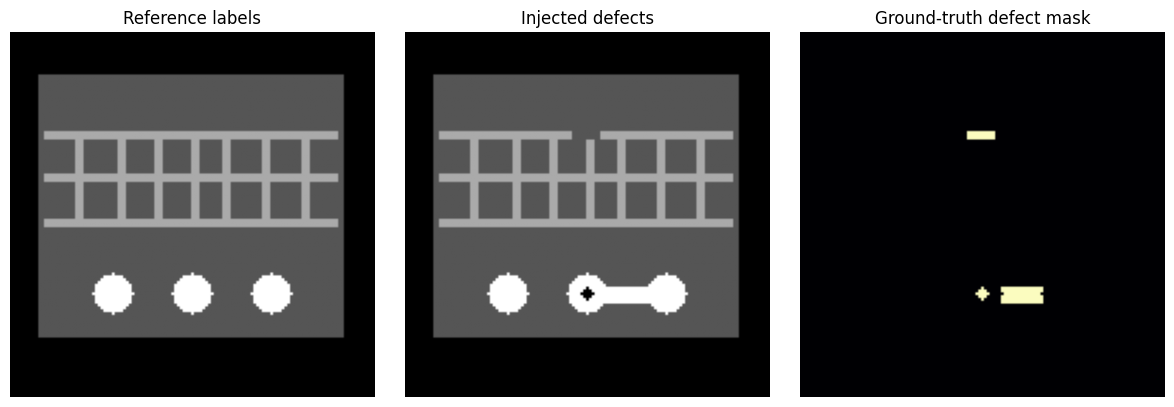

In [5]:
N = config.volume_shape_zyx[-1]
reference_labels = make_package_slice(N, seed=config.seed)
candidate_labels, defect_truth = inject_demo_defects(reference_labels)
attenuation = material_to_attenuation(candidate_labels)
print({name: int(mask.sum()) for name, mask in defect_truth.items()})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(reference_labels, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Reference labels')
axes[1].imshow(candidate_labels, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Injected defects')
axes[2].imshow(reference_labels != candidate_labels, cmap='magma')
axes[2].set_title('Ground-truth defect mask')
for ax in axes: ax.axis('off')
plt.tight_layout();

## ASTRA forward projection and filtered backprojection

Forward projections are converted to transmission with Beer–Lambert, perturbed with Poisson counting noise, converted back to line integrals, and reconstructed with a Hann-filtered FBP. CUDA is selected when available; otherwise the same notebook falls back to ASTRA CPU.

In [6]:
started = time.perf_counter()
angles = np.linspace(0, np.pi, config.projections, endpoint=False)
detector_pixels = config.detector_shape_rc[1]
proj_geom = astra.create_proj_geom('parallel', 1.0, detector_pixels, angles)
vol_geom = astra.create_vol_geom(N, N)
use_cuda = bool(astra.use_cuda())
projector_id = astra.create_projector('cuda' if use_cuda else 'linear', proj_geom, vol_geom)
sinogram_id = noisy_sinogram_id = recon_id = algorithm_id = None
try:
    sinogram_id, line_integrals = astra.create_sino(attenuation, projector_id)
    photon_count = 100_000
    rng = np.random.default_rng(config.seed)
    transmission = np.exp(-np.clip(line_integrals, 0, 20))
    counts = rng.poisson(transmission * photon_count)
    noisy_line_integrals = -np.log(np.clip(counts / photon_count, 1 / photon_count, 1.0)).astype(np.float32)
    noisy_sinogram_id = astra.data2d.create('-sino', proj_geom, noisy_line_integrals)
    recon_id = astra.data2d.create('-vol', vol_geom)
    algorithm_name = 'FBP_CUDA' if use_cuda else 'FBP'
    cfg = astra.astra_dict(algorithm_name)
    cfg['ProjectionDataId'] = noisy_sinogram_id
    cfg['ReconstructionDataId'] = recon_id
    cfg['option'] = {'FilterType': 'hann'}
    if not use_cuda:
        cfg['ProjectorId'] = projector_id
    algorithm_id = astra.algorithm.create(cfg)
    astra.algorithm.run(algorithm_id)
    reconstruction = astra.data2d.get(recon_id).astype(np.float32)
finally:
    if algorithm_id is not None: astra.algorithm.delete(algorithm_id)
    astra.data2d.delete([item for item in (sinogram_id, noisy_sinogram_id, recon_id) if item is not None])
    astra.projector.delete(projector_id)
elapsed = time.perf_counter() - started

reconstruction = np.clip(reconstruction, 0, None)
truth_norm = attenuation / max(float(attenuation.max()), 1e-12)
recon_norm = reconstruction / max(float(reconstruction.max()), 1e-12)
nrmse = float(np.sqrt(np.mean((truth_norm - recon_norm) ** 2)))
print({'algorithm': algorithm_name, 'elapsed_seconds': round(elapsed, 3), 'normalized_rmse': round(nrmse, 4)})

{'algorithm': 'FBP_CUDA', 'elapsed_seconds': 0.234, 'normalized_rmse': 0.2448}


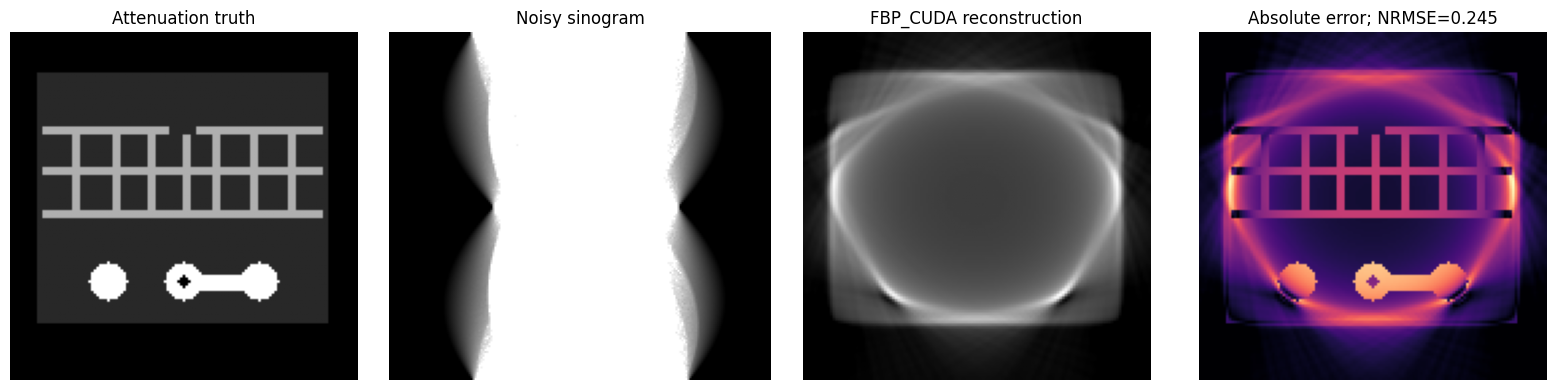

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(attenuation, cmap='gray')
axes[0].set_title('Attenuation truth')
axes[1].imshow(noisy_line_integrals, cmap='gray', aspect='auto')
axes[1].set_title('Noisy sinogram')
axes[2].imshow(recon_norm, cmap='gray')
axes[2].set_title(f'{algorithm_name} reconstruction')
axes[3].imshow(np.abs(truth_norm - recon_norm), cmap='magma')
axes[3].set_title(f'Absolute error; NRMSE={nrmse:.3f}')
for ax in axes: ax.axis('off')
plt.tight_layout();

## Save reproducibility artefacts

The manifest records configuration, package versions, runtime, GPU identity, elapsed time, and the transparent memory estimate. Generated arrays remain outside Git.

In [8]:
output_dir = Path('/content/xsim_outputs')
output_dir.mkdir(parents=True, exist_ok=True)
manifest = build_run_manifest(config, elapsed_seconds=elapsed)
manifest['result'] = {'algorithm': algorithm_name, 'normalized_rmse': nrmse, 'photon_count': photon_count}
(output_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
np.save(output_dir / 'reference_labels.npy', reference_labels)
np.save(output_dir / 'candidate_labels.npy', candidate_labels)
np.save(output_dir / 'noisy_sinogram.npy', noisy_line_integrals)
np.save(output_dir / 'reconstruction.npy', reconstruction)
print(json.dumps(manifest, indent=2))
print('Saved to', output_dir)

{
  "schema_version": "1.0",
  "created_utc": "2026-09-08T21:00:08.789741+00:00",
  "config": {
    "profile": "quick-colab",
    "volume_shape_zyx": [
      129,
      129,
      129
    ],
    "detector_shape_rc": [
      129,
      192
    ],
    "projections": 180,
    "voxel_size_um": 16.0,
    "seed": 2060
  },
  "memory_estimate": {
    "label_volume_uint8_gib": 0.002,
    "working_volume_float32_gib": 0.008,
    "projection_stack_float32_gib": 0.0166,
    "projection_stack_uint16_gib": 0.0083,
    "reconstruction_float32_gib": 0.008,
    "declared_numpy_buffers_gib": 0.0429,
    "streamed_projection_floor_gib": 0.0263
  },
  "runtime": {
    "python": "3.13.15",
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
    "is_google_colab": true,
    "colab_release_tag": "release-colab-external-images_20260902-060045_RC00",
    "gpu": {
      "available": "true",
      "description": "Tesla T4, 580.82.07, 15360"
    },
    "elapsed_seconds": 0.23367319499993755
  },
  "packages"